# Pipeline RF

In [17]:
# importazione librerie necessarie
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gzip
import numpy as np

# modello da allenare (Random Forest)
from sklearn.ensemble import RandomForestClassifier

# importazione metriche di valutazione e utilità al fine dell'allenamento dei modelli
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

# per fare Oversampling/Undersampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [18]:
# features variabili su cui andare ad allenare i modelli (DA CAMBIARE PER RUN DIVERSE) [DATASET NON NORMALIZZATO]
features = ['avg_position','avg_position_1','avg_position_2','avg_position_3','avg_position_4','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','avg_position_2','avg_position_3','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','avg_position_2','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']

In [19]:
# features variabili su cui andare ad allenare i modelli (DA CAMBIARE PER RUN DIVERSE) [DATASET NORMALIZZATO]
features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','avg_position_3_startlist','avg_position_4_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','avg_position_3_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']

In [20]:
# DATA TO SAVE IN ADDITION TO CLASSIFICATION REPORT AND CONFUSION MATRIX FOR EACH MODEL

# model_name = ""
# dataset = ""
# features_dataset = []

##  Not normalized dataset

Best Hyperparameters: 
n_estimators=200,criterion="gini",max_depth=10,min_samples_split=2,min_samples_leaf=5,class_weight="balanced",random_state=42

In [21]:
# Take the merged dataset cleaned from null values and anomalies
with gzip.open('../../dataset/train_set.pkl', 'r') as file:
    train_set = pickle.load(file)
with gzip.open('../../dataset/test_set.pkl', 'r') as file:
    test_set = pickle.load(file)

In [22]:
model_name = "RF"
dataset = "dataset_non_normalizzato"
features_dataset = features

In [23]:
print("Train_set shape before dropping NaN:",train_set.shape)
print("Test_set shape before dropping NaN:",test_set.shape)
train_set = train_set.dropna()
test_set = test_set.dropna()
print("Train_set shape post dropping NaN:",train_set.shape)
print("Test_set shape post dropping NaN:",test_set.shape)

X_train = train_set[features]
y_train = train_set['top20']

X_test = test_set[features]
y_test = test_set['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (405899, 35)
Test_set shape before dropping NaN: (35406, 35)
Train_set shape post dropping NaN: (390572, 35)
Test_set shape post dropping NaN: (34258, 35)
X_train shape: (390572, 9)
y_train shape: (390572,)
X_test shape: (34258, 9)
y_test shape: (34258,)


In [24]:
# BEST model
RF = RandomForestClassifier(n_estimators=200,criterion="gini",max_depth=10,min_samples_split=2,min_samples_leaf=5,class_weight="balanced",random_state=42)     

In [25]:
RF.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=200, random_state=42)

In [26]:
y_train_pred = RF.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.73      0.82    336829
           1       0.30      0.72      0.42     53743

    accuracy                           0.73    390572
   macro avg       0.62      0.72      0.62    390572
weighted avg       0.85      0.73      0.77    390572



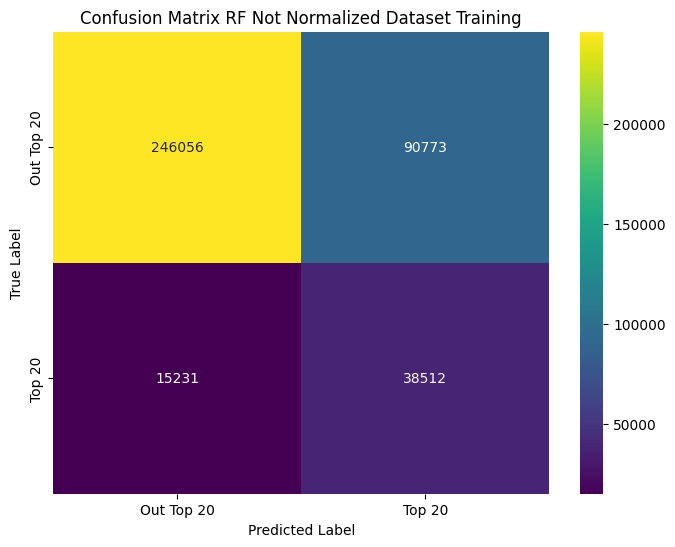

In [27]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Not Normalized Dataset Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [28]:
y_pred = RF.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.67      0.78     29163
           1       0.28      0.75      0.41      5095

    accuracy                           0.68     34258
   macro avg       0.61      0.71      0.59     34258
weighted avg       0.84      0.68      0.72     34258



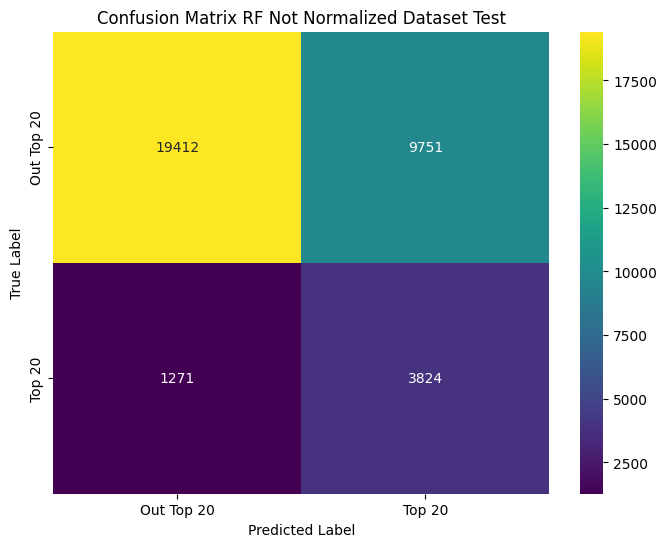

In [29]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Not Normalized Dataset Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [30]:
# # save results
# with open("./stuffs/results/GS/RF_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

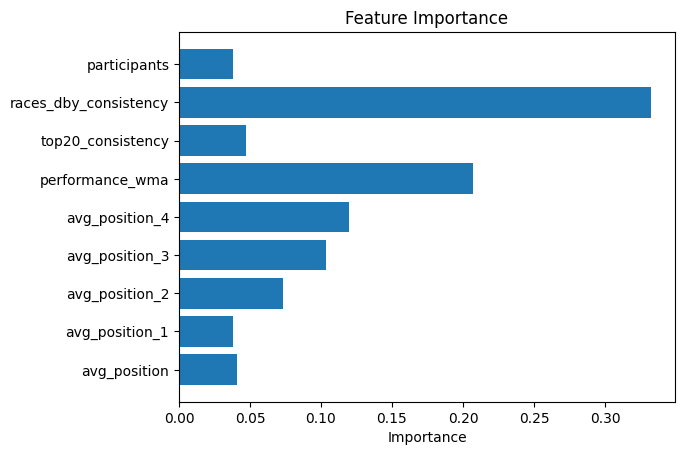

In [31]:
import matplotlib.pyplot as plt

importance = RF.feature_importances_

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

### Oversampling/Undersampling

In [32]:
model_name = "RF"
dataset = "dataset_non_normalizzato_con_oversampling"
features_dataset = features

In [33]:
print("Train_set shape before dropping NaN:",train_set.shape)
print("Test_set shape before dropping NaN:",test_set.shape)
train_set = train_set.dropna()
test_set = test_set.dropna()
print("Train_set shape post dropping NaN:",train_set.shape)
print("Test_set shape post dropping NaN:",test_set.shape)

X_train = train_set[features]
y_train = train_set['top20']

X_test = test_set[features]
y_test = test_set['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (390572, 35)
Test_set shape before dropping NaN: (34258, 35)
Train_set shape post dropping NaN: (390572, 35)
Test_set shape post dropping NaN: (34258, 35)
X_train shape: (390572, 9)
y_train shape: (390572,)
X_test shape: (34258, 9)
y_test shape: (34258,)


In [34]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 336829, 1: 53743})


In [35]:
# Applica SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [36]:
# Controlla la distribuzione dopo SMOTE
print("Distribuzione dopo SMOTE:", Counter(y_train_resampled))

Distribuzione dopo SMOTE: Counter({1: 336829, 0: 336829})


In [37]:
# BEST model
RF = RandomForestClassifier(n_estimators=200,criterion="gini",max_depth=10,min_samples_split=2,min_samples_leaf=5,class_weight="balanced",random_state=42)     

In [38]:
RF.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=200, random_state=42)

In [39]:
y_train_resampled_pred = RF.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.75      0.71      0.73    336829
           1       0.73      0.77      0.75    336829

    accuracy                           0.74    673658
   macro avg       0.74      0.74      0.74    673658
weighted avg       0.74      0.74      0.74    673658



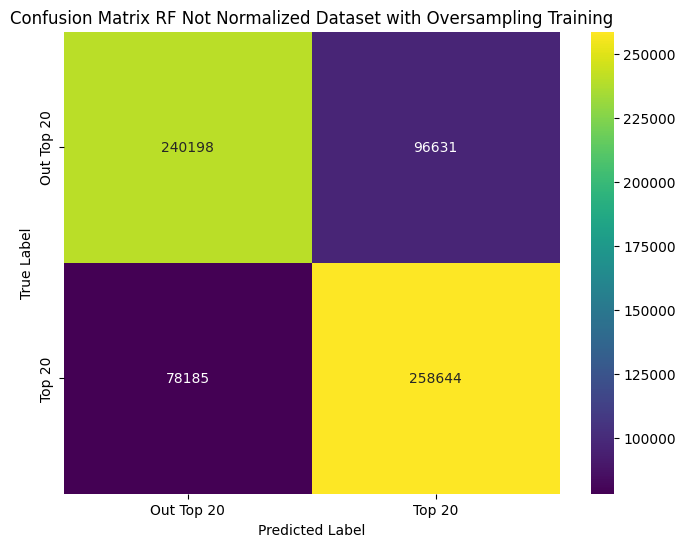

In [40]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Not Normalized Dataset with Oversampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [41]:
y_pred = RF.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.63      0.75     29163
           1       0.27      0.77      0.39      5095

    accuracy                           0.65     34258
   macro avg       0.60      0.70      0.57     34258
weighted avg       0.84      0.65      0.70     34258



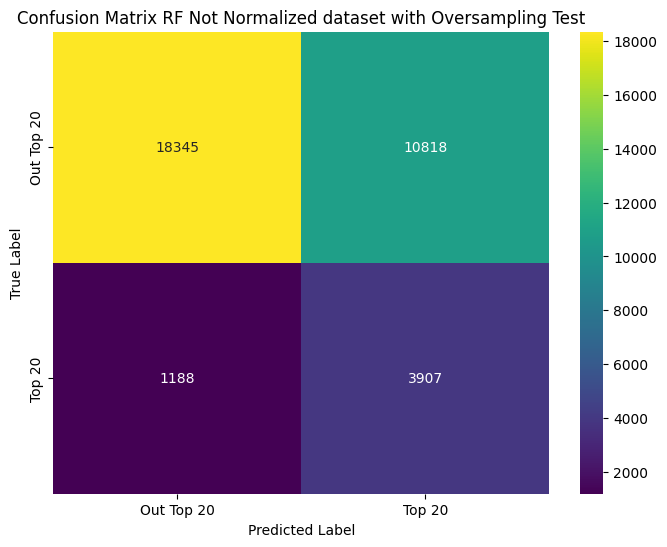

In [42]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Not Normalized dataset with Oversampling Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [43]:
# # save results
# with open("./stuffs/results/GS/RF_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

In [44]:
model_name = "RF"
dataset = "dataset_non_normalizzato_con_undersampling"
features_dataset = features

In [45]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 336829, 1: 53743})


In [46]:
# Applica Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [47]:
# Controlla la distribuzione dopo l'undersampling
print("Distribuzione dopo Random Undersampling:", Counter(y_train_resampled))

Distribuzione dopo Random Undersampling: Counter({0: 53743, 1: 53743})


In [48]:
# BEST model
RF = RandomForestClassifier(n_estimators=200,criterion="gini",max_depth=10,min_samples_split=2,min_samples_leaf=5,class_weight="balanced",random_state=42)     

In [49]:
RF.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=200, random_state=42)

In [50]:
y_train_resampled_pred = RF.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.73      0.73      0.73     53743
           1       0.73      0.73      0.73     53743

    accuracy                           0.73    107486
   macro avg       0.73      0.73      0.73    107486
weighted avg       0.73      0.73      0.73    107486



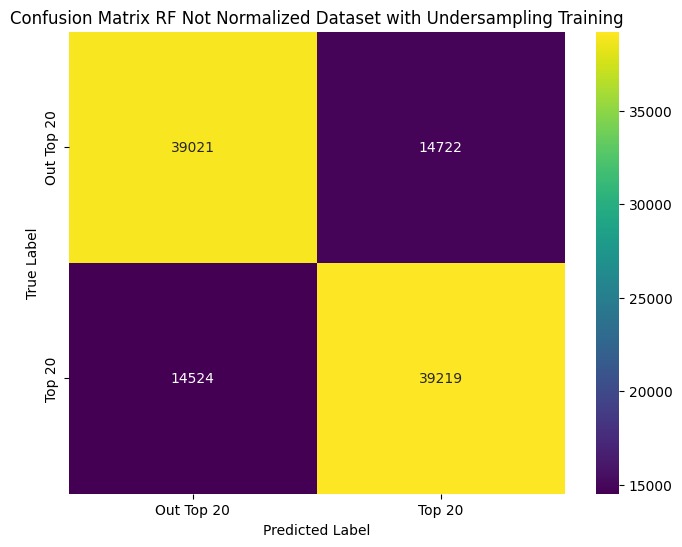

In [51]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Not Normalized Dataset with Undersampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [52]:
y_pred = RF.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.65      0.77     29163
           1       0.28      0.77      0.40      5095

    accuracy                           0.66     34258
   macro avg       0.61      0.71      0.59     34258
weighted avg       0.84      0.66      0.71     34258



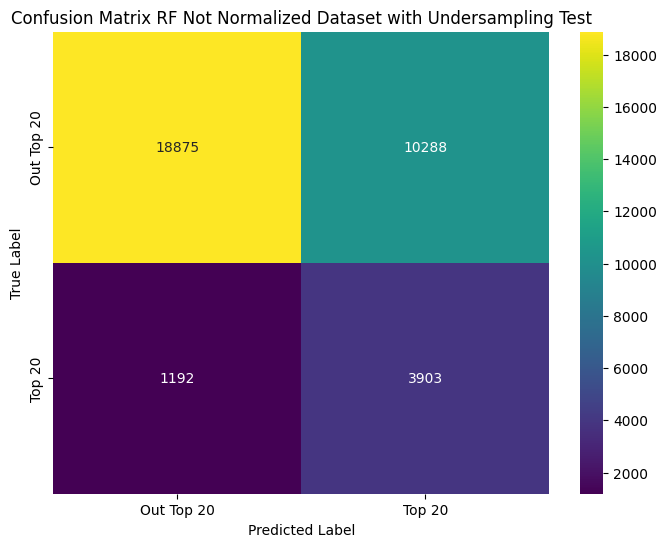

In [53]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Not Normalized Dataset with Undersampling Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [54]:
# # save results
# with open("./stuffs/results/GS/RF_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

## Normalized dataset

Best Hyperparameters:
n_estimators=200,criterion="gini",max_depth=10,min_samples_split=2,min_samples_leaf=2,class_weight="balanced",random_state=42

In [55]:
# Take the normalized merged dataset cleaned from null values and anomalies
with gzip.open('../../dataset/train_set_normalized.pkl', 'r') as file:
    train_set_n = pickle.load(file)
with gzip.open('../../dataset/test_set_normalized.pkl', 'r') as file:
    test_set_n = pickle.load(file)

In [56]:
model_name = "RF"
dataset = "dataset_normalizzato"
features_dataset = features_n

In [57]:
print("Train_set shape before dropping NaN:",train_set_n.shape)
print("Test_set shape before dropping NaN:",test_set_n.shape)
train_set_n = train_set_n.dropna()
test_set_n = test_set_n.dropna()
print("Train_set shape post dropping NaN:",train_set_n.shape)
print("Test_set shape post dropping NaN:",test_set_n.shape)

X_train = train_set_n[features_n]
y_train = train_set_n['top20']

X_test = test_set_n[features_n]
y_test = test_set_n['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (405899, 37)
Test_set shape before dropping NaN: (35406, 37)
Train_set shape post dropping NaN: (394206, 37)
Test_set shape post dropping NaN: (34509, 37)
X_train shape: (394206, 9)
y_train shape: (394206,)
X_test shape: (34509, 9)
y_test shape: (34509,)


In [58]:
# BEST model
RF = RandomForestClassifier(n_estimators=200,criterion="gini",max_depth=10,min_samples_split=2,min_samples_leaf=2,class_weight="balanced",random_state=42)     

In [59]:
RF.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=200, random_state=42)

In [60]:
y_train_pred = RF.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.73      0.82    340134
           1       0.30      0.72      0.42     54072

    accuracy                           0.73    394206
   macro avg       0.62      0.72      0.62    394206
weighted avg       0.85      0.73      0.77    394206



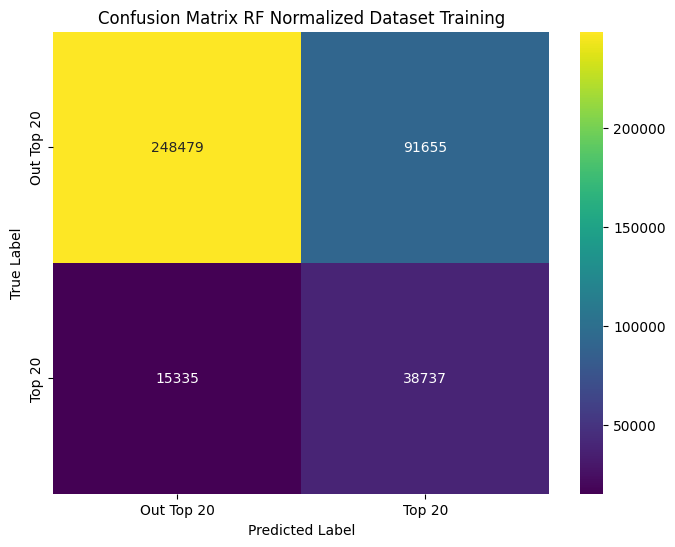

In [61]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Normalized Dataset Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [62]:
y_pred = RF.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.67      0.78     29391
           1       0.28      0.74      0.41      5118

    accuracy                           0.68     34509
   macro avg       0.61      0.71      0.60     34509
weighted avg       0.84      0.68      0.73     34509



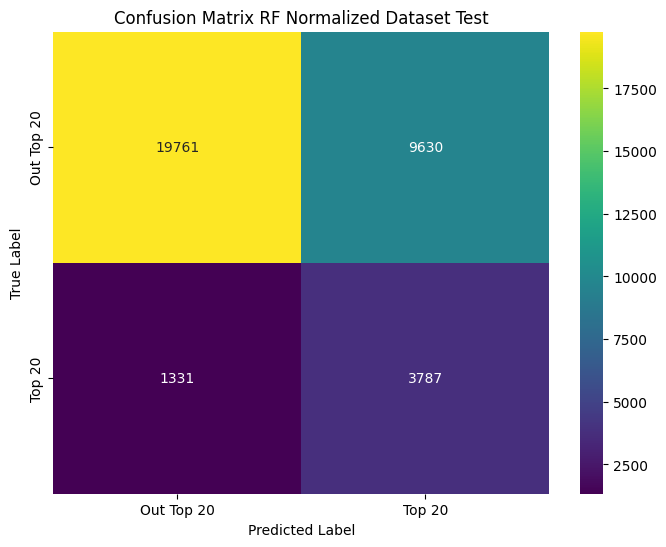

In [63]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Normalized Dataset Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [64]:
# # save results
# with open("./stuffs/results/GS/RF_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

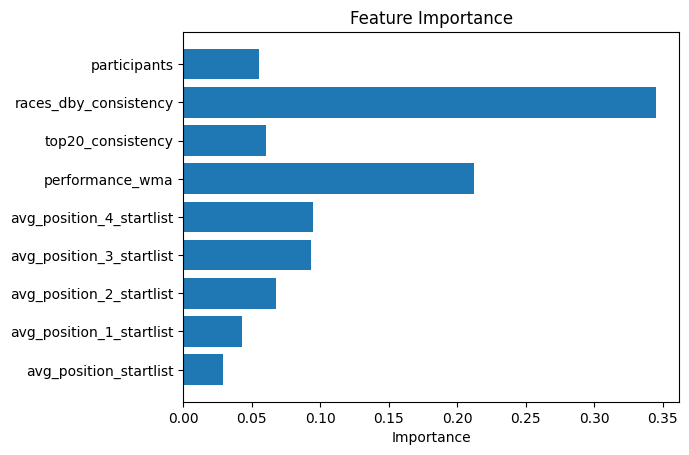

In [65]:
import matplotlib.pyplot as plt

importance = RF.feature_importances_

plt.barh(features_n, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

### Oversampling/Undersampling

In [66]:
model_name = "RF"
dataset = "dataset_normalizzato_con_oversampling"
features_dataset = features_n

In [67]:
print("Train_set shape before dropping NaN:",train_set_n.shape)
print("Test_set shape before dropping NaN:",test_set_n.shape)
train_set_n = train_set_n.dropna()
test_set_n = test_set_n.dropna()
print("Train_set shape post dropping NaN:",train_set_n.shape)
print("Test_set shape post dropping NaN:",test_set_n.shape)

X_train = train_set_n[features_n]
y_train = train_set_n['top20']

X_test = test_set_n[features_n]
y_test = test_set_n['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (394206, 37)
Test_set shape before dropping NaN: (34509, 37)
Train_set shape post dropping NaN: (394206, 37)
Test_set shape post dropping NaN: (34509, 37)
X_train shape: (394206, 9)
y_train shape: (394206,)
X_test shape: (34509, 9)
y_test shape: (34509,)


In [68]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 340134, 1: 54072})


In [69]:
# Applica SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [70]:
# Controlla la distribuzione dopo SMOTE
print("Distribuzione dopo SMOTE:", Counter(y_train_resampled))

Distribuzione dopo SMOTE: Counter({1: 340134, 0: 340134})


In [71]:
# BEST model
RF = RandomForestClassifier(n_estimators=200,criterion="gini",max_depth=10,min_samples_split=2,min_samples_leaf=2,class_weight="balanced",random_state=42)     

In [72]:
RF.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=200, random_state=42)

In [73]:
y_train_resampled_pred = RF.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.74      0.72      0.73    340134
           1       0.73      0.75      0.74    340134

    accuracy                           0.74    680268
   macro avg       0.74      0.74      0.74    680268
weighted avg       0.74      0.74      0.74    680268



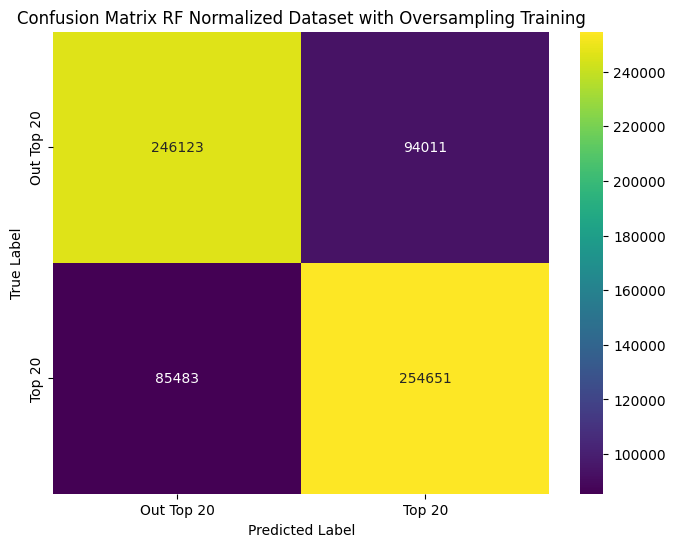

In [74]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Normalized Dataset with Oversampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [75]:
y_pred = RF.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.93      0.66      0.77     29391
           1       0.27      0.72      0.39      5118

    accuracy                           0.67     34509
   macro avg       0.60      0.69      0.58     34509
weighted avg       0.83      0.67      0.72     34509



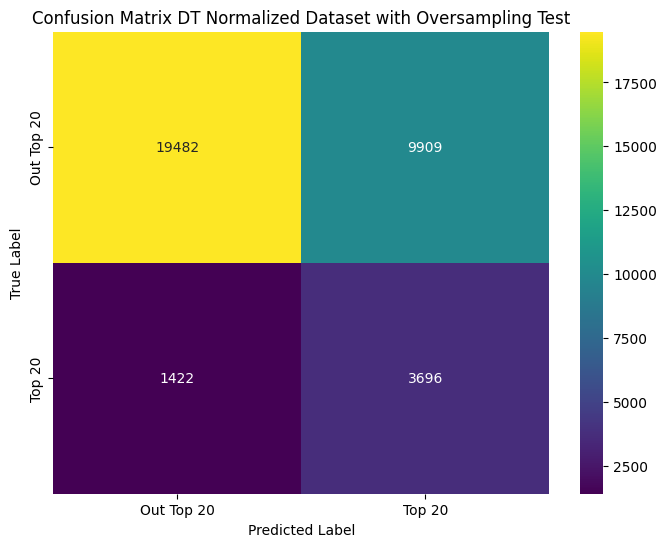

In [76]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix DT Normalized Dataset with Oversampling Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [77]:
# # save results
# with open("./stuffs/results/GS/RF_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

In [78]:
model_name = "RF"
dataset = "dataset_normalizzato_con_undersampling"
features_dataset = features_n

In [79]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 340134, 1: 54072})


In [80]:
# Applica Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [81]:
# Controlla la distribuzione dopo l'undersampling
print("Distribuzione dopo Random Undersampling:", Counter(y_train_resampled))

Distribuzione dopo Random Undersampling: Counter({0: 54072, 1: 54072})


In [82]:
# BEST model
RF = RandomForestClassifier(n_estimators=200,criterion="gini",max_depth=10,min_samples_split=2,min_samples_leaf=2,class_weight="balanced",random_state=42)     

In [83]:
RF.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, n_estimators=200, random_state=42)

In [84]:
y_train_resampled_pred = RF.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.73      0.73      0.73     54072
           1       0.73      0.73      0.73     54072

    accuracy                           0.73    108144
   macro avg       0.73      0.73      0.73    108144
weighted avg       0.73      0.73      0.73    108144



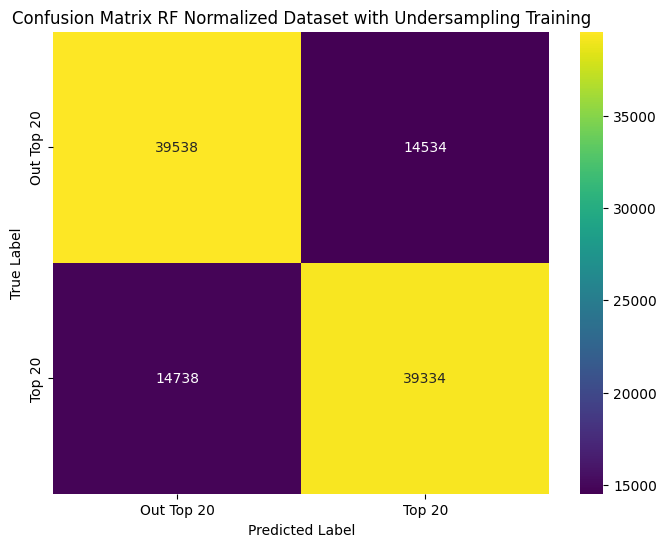

In [85]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Normalized Dataset with Undersampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [86]:
y_pred = RF.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.65      0.77     29391
           1       0.27      0.77      0.40      5118

    accuracy                           0.66     34509
   macro avg       0.61      0.71      0.58     34509
weighted avg       0.84      0.66      0.71     34509



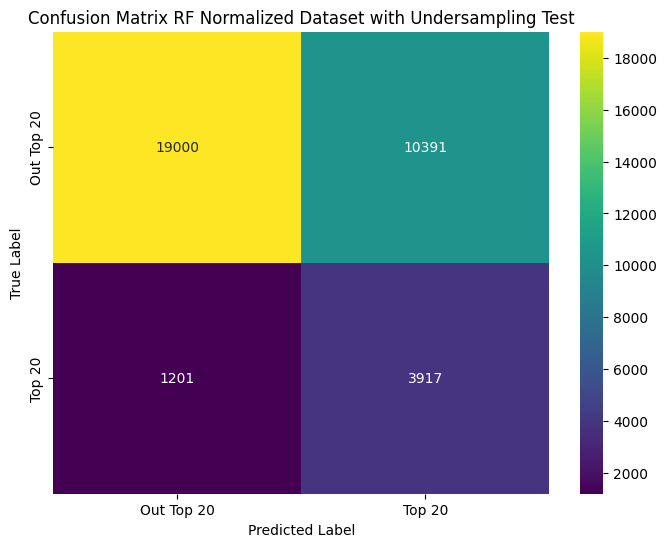

In [87]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix RF Normalized Dataset with Undersampling Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [88]:
# # save results
# with open("./stuffs/results/GS/RF_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")